### Carga de datos y estadísticas descriptivas

In [0]:
from pyspark.sql.functions import col

# Cargar la tabla limpia desde el catálogo default
df_citas = spark.table("default.citas_pmm_limpioV2")

# Verificar el número total de registros cargados
print(f"Total de registros para el EDA: {df_citas.count()}")

# Estadísticas descriptivas de variables biométricas y numéricas
columnas_biometricas = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "mins_cit"]
print("\n--- Resumen Estadístico de Variables Biométricas ---")
df_citas.select(columnas_biometricas).summary().display()

# Estadísticas descriptivas de variables financieras
columnas_financieras = ["pago_clie", "pago_aseg", "pago_total"]
print("\n--- Resumen Estadístico de Variables Financieras ---")
df_citas.select(columnas_financieras).summary().display()

Total de registros para el EDA: 10000

--- Resumen Estadístico de Variables Biométricas ---


summary,edad_pac_cita,peso_kg,altura_m,imc,mins_cit
count,10000,10000,10000,10000,10000
mean,41.2222,59.832640000000026,1.5067499999999951,24.192920000000033,37.23
stddev,26.281691343785102,26.113008435478164,0.31218174713510194,5.7830246593820736,16.82677669791227
min,0,3.5,0.5,14.0,15
25%,18,47.5,1.53,19.2,15
50%,40,65.3,1.62,24.4,30
75%,61,78.0,1.69,28.4,45
max,96,132.0,1.94,45.0,60



--- Resumen Estadístico de Variables Financieras ---


summary,pago_clie,pago_aseg,pago_total
count,10000,10000,10000
mean,18.931410000000028,21.32408999999997,40.2555
stddev,18.37960725826846,19.16499861594296,23.25943507228814
min,0.0,0.0,0.0
25%,6.15,0.0,25.0
50%,13.89,24.81,45.0
75%,25.0,36.45,55.0
max,75.0,67.47,75.0


### Análisis de Distribuciones de Variables Categóricas y Numéricas

In [0]:
import pyspark.sql.functions as F

print("\n--- 1. Extracción de Características Temporales ---")
# Creación de nuevas variables (Feature Engineering básico)
df_citas = df_citas.withColumn("dia_semana", F.dayofweek("fecha_cit")) \
                   .withColumn("mes", F.month("fecha_cit")) \
                   .withColumn("hora_inicio", F.hour("hr_inicio_cit"))

# Volumen de citas por hora del día para identificar horas pico
print("Distribución de Citas por Hora de Inicio:")
df_citas.groupBy("hora_inicio").count().orderBy("hora_inicio").display()

print("\n--- 2. Análisis Bivariado: Ausentismo vs. Factores Operativos ---")

# Tasa de estado de cita cruzada con la Sucursal (Identificar si la ubicación afecta el ausentismo)
print("Estado de Citas por Sucursal:")
df_citas.crosstab("nom_sucursal", "estado_cita").display()

# Tasa de estado de cita cruzada con el Día de la Semana
print("Estado de Citas por Día de la Semana:")
df_citas.crosstab("dia_semana", "estado_cita").display()

print("\n--- Análisis Bivariado: Carga Financiera ---")
# Promedio de facturación total agrupado por Especialidad
# Útil si el objetivo es predecir costos
df_citas.groupBy("especialidad_medica") \
    .agg(
          F.round(F.avg("pago_total"),2).alias("Promedio_Pago_Total"),
          F.round(F.sum("pago_total"),2).alias("Ingreso_Total_Historico")) \
    .orderBy("Promedio_Pago_Total", ascending=False).display()


--- 1. Extracción de Características Temporales ---
Distribución de Citas por Hora de Inicio:


hora_inicio,count
8,1496
9,1445
10,1021
11,492
12,522
13,507
14,997
15,1028
16,1499
17,993



--- 2. Análisis Bivariado: Ausentismo vs. Factores Operativos ---
Estado de Citas por Sucursal:


nom_sucursal_estado_cita,Cancelada,Completada
PMM El Dorado,411,1608
PMM Costa del Este,454,2067
PMM San Francisco,564,2426
PMM Tocumen,195,823
PMM Brisas del Golf,307,1145


Estado de Citas por Día de la Semana:


dia_semana_estado_cita,Cancelada,Completada
7,171,600
5,151,1376
6,574,1337
1,110,100
4,188,1626
3,271,1531
2,466,1499



--- Análisis Bivariado: Carga Financiera ---


especialidad_medica,Promedio_Pago_Total,Ingreso_Total_Historico
Neurología,60.73,35100.0
Nefrología,57.29,32830.0
Cardiología,54.85,26600.0
Gastroenterología,53.23,29705.0
Psiquiatría,47.57,26640.0
Geriatría,43.91,6850.0
Radiología,42.68,37345.0
Dermatología,40.76,35500.0
Otorrinolaringología,40.66,34600.0
Oftalmología,37.14,33165.0


In [0]:
# Proporción de citas por estado
print("\n--- Estado de las Citas ---")
df_citas.groupBy("estado_cita").count()\
    .withColumnRenamed("estado_cita", "Estado") \
    .withColumnRenamed("count", "Total de Citas") \
    .orderBy("Total de Citas", ascending=False).display()


# Distribución de citas por Sucursal
print("--- Volumen de Citas por Sucursal ---")
df_citas.groupBy("nom_sucursal").count() \
    .withColumnRenamed("nom_sucursal", "Sucursal") \
    .withColumnRenamed("count", "Total de Citas") \
    .orderBy("Total de Citas", ascending=False).display()


# Distribución de citas por Aseguradora
print("\n--- Volumen de Citas por Aseguradora ---")
df_citas.groupBy("nom_aseguradora").count()\
    .withColumnRenamed("nom_aseguradora", "Aseguradora") \
    .withColumnRenamed("count", "Total de Citas") \
    .orderBy("Total de Citas", ascending=False).display()


# Top 5 de Especialidades Médicas con mayor demanda
print("\n--- Top 5 Especialidades Médicas ---")
df_citas.groupBy("especialidad_medica").count()\
    .withColumnRenamed("especialidad_medica", "Especialidad Médica") \
    .withColumnRenamed("count", "Cantidad de Doctores") \
    .orderBy("Cantidad de Doctores", ascending=False).limit(5).display()


# Top 20 motivos más comunes
print("\n--- Motivos ---")
df_citas.groupBy("motivo_cita").count().orderBy("count", ascending=False).limit(20).display()



--- Estado de las Citas ---


Estado,Total de Citas
Completada,8069
Cancelada,1931


--- Volumen de Citas por Sucursal ---


Sucursal,Total de Citas
PMM San Francisco,2990
PMM Costa del Este,2521
PMM El Dorado,2019
PMM Brisas del Golf,1452
PMM Tocumen,1018



--- Volumen de Citas por Aseguradora ---


Aseguradora,Total de Citas
Particular / Sin Seguro,2442
Seguros ASSA,1595
PALIG,1575
MAPFRE Panamá,1502
Compañía Internacional de Seguros (IS),1462
Seguros SURA,1424



--- Top 5 Especialidades Médicas ---


Especialidad Médica,Cantidad de Doctores
Medicina General,907
Oftalmología,893
Fisioterapia,877
Radiología,875
Dermatología,871



--- Motivos ---


motivo_cita,count
Control de Presión,321
Presión Ocular,316
Mamografía,311
Resfriado,304
Evaluación de Lunares,301
Problemas de Garganta,301
Sinusitis Crónica,299
Rehabilitación de Rodilla,295
Limpieza Dental,292
Lesión,292


### Correlaciones Visuales - Mapa de Calor

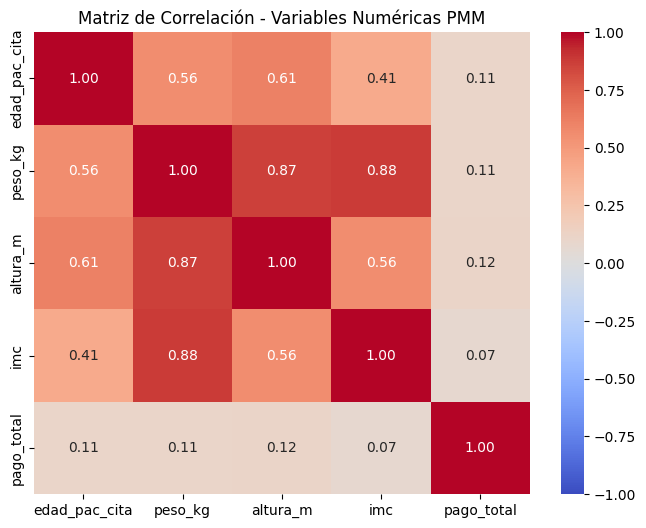

In [0]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las variables numéricas continuas clave
columnas_num = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "pago_total"]

# Ensamblar las columnas en un vector denso (Requisito de Spark ML)
assembler = VectorAssembler(inputCols=columnas_num, outputCol="features")
df_vector = assembler.transform(df_citas.select(columnas_num))

# Calcular la matriz de correlación de Pearson
matrix = Correlation.corr(df_vector, "features").collect()[0][0]
corr_matrix = matrix.toArray().tolist()

# Convertir a un DataFrame de Pandas para poder usar Seaborn
df_corr = pd.DataFrame(corr_matrix, index=columnas_num, columns=columnas_num)

# Dibujar el mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Variables Numéricas PMM")
plt.show()

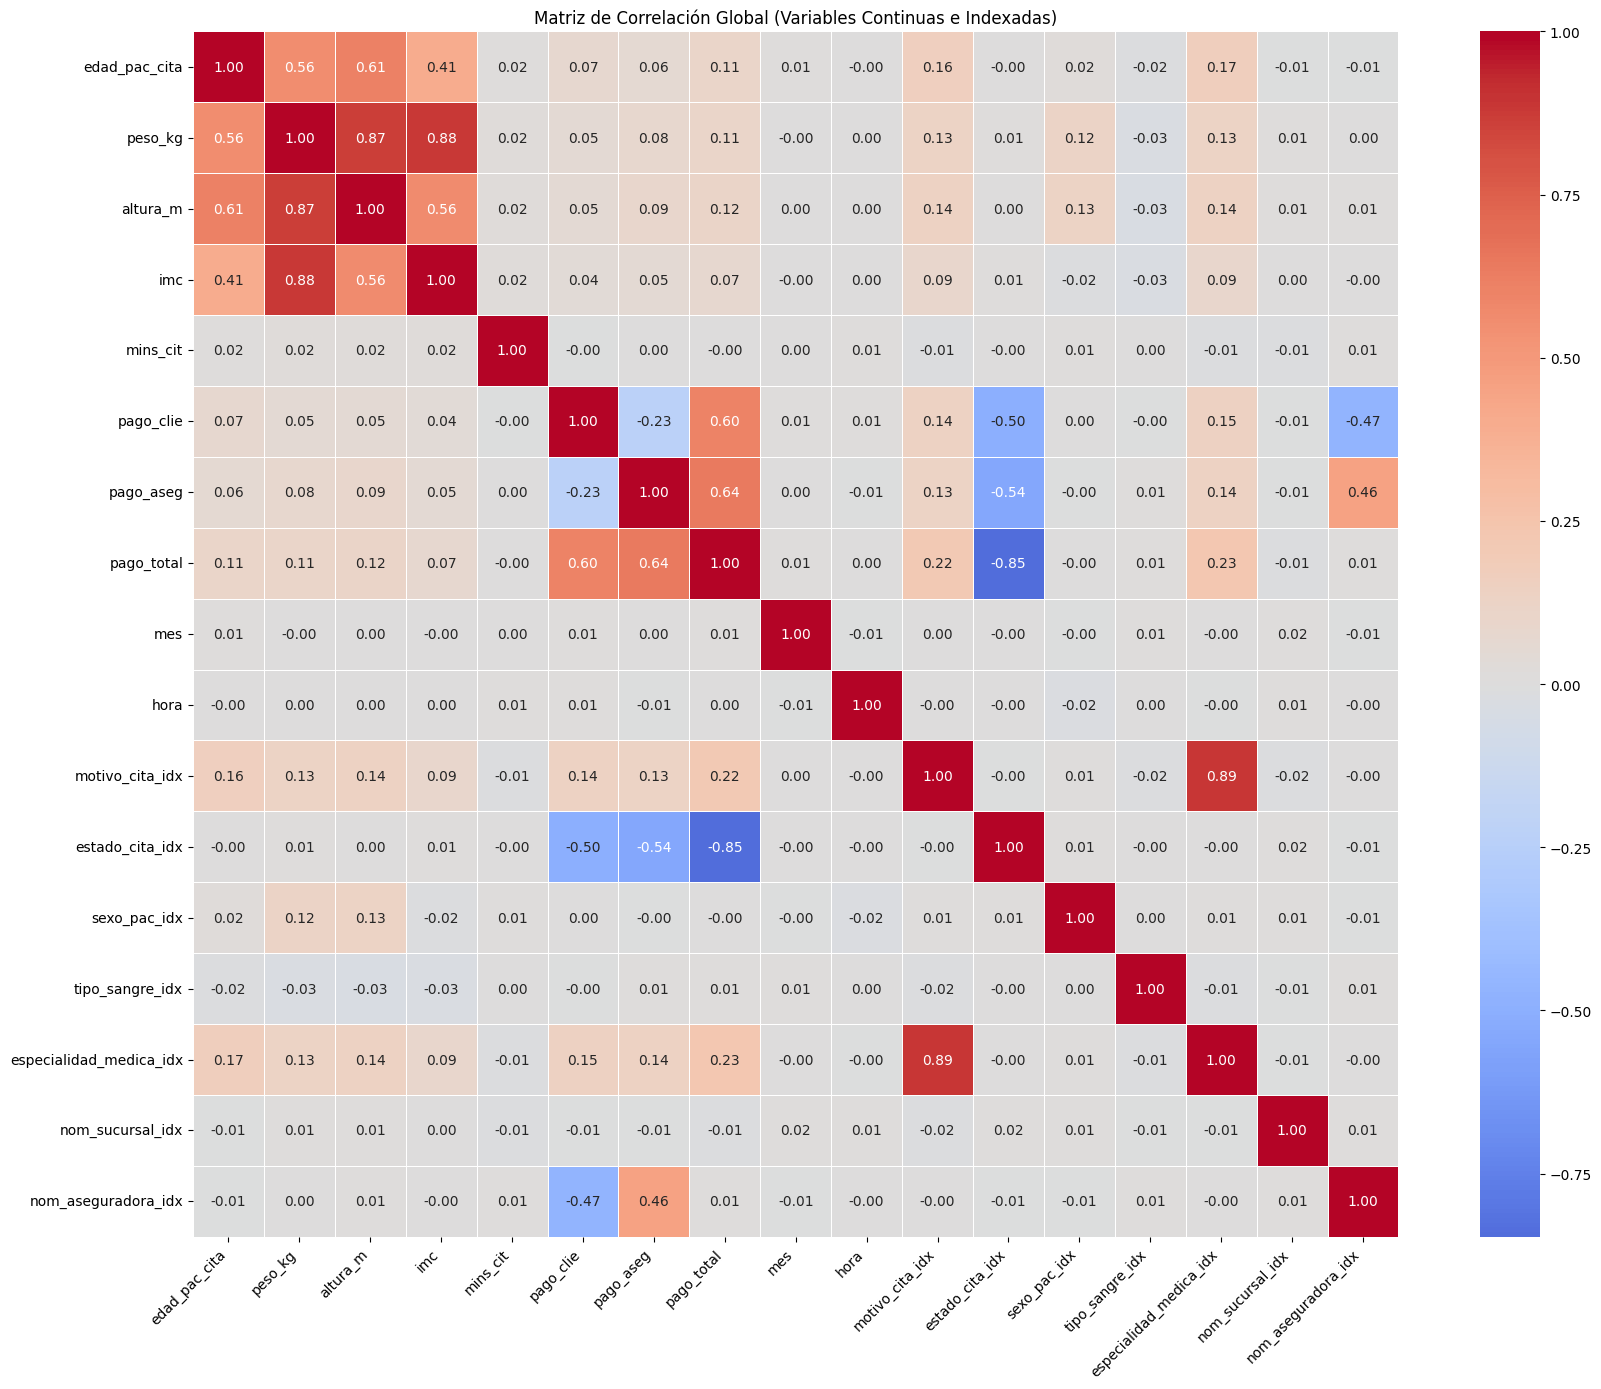

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
import pyspark.sql.functions as F

# 1. Ingeniería de Características: Extraer variables numéricas de las fechas temporales
df_prep = df_citas.withColumn("mes", F.month("fecha_cit")) \
                  .withColumn("hora", F.hour("hr_inicio_cit"))

# 2. Definición de dominios de variables (excluyendo IDs y textos libres si los hubiera)
cols_numericas = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "mins_cit", 
                  "pago_clie", "pago_aseg", "pago_total", "mes", "hora"]

cols_categoricas = ["motivo_cita", "estado_cita", "sexo_pac", "tipo_sangre", 
                    "especialidad_medica", "nom_sucursal", "nom_aseguradora"]

# 3. Codificación de Variables Categóricas (StringIndexer)
# handleInvalid="skip" previene errores si hay valores anómalos o nulos imprevistos
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="skip") for c in cols_categoricas]

# Ejecutar el pipeline de transformación
pipeline = Pipeline(stages=indexers)
df_indexed = pipeline.fit(df_prep).transform(df_prep)

# 4. Consolidación de columnas para la matriz
cols_categoricas_idx = [f"{c}_idx" for c in cols_categoricas]
todas_las_columnas = cols_numericas + cols_categoricas_idx

# Las matrices de correlación requieren datasets sin valores nulos (NaN)
df_clean = df_indexed.select(todas_las_columnas).dropna()

# 5. Vectorización de los datos (Requisito estricto de PySpark MLlib)
assembler = VectorAssembler(inputCols=todas_las_columnas, outputCol="features")
df_vector = assembler.transform(df_clean).select("features")

# 6. Cálculo de la Matriz de Correlación (Pearson)
matriz_spark = Correlation.corr(df_vector, "features").head()[0].toArray()

# 7. Renderizado Visual (Heatmap)
# Se transfiere la matriz matemática a Pandas para utilizar la librería Seaborn
df_corr = pd.DataFrame(matriz_spark, index=todas_las_columnas, columns=todas_las_columnas)

plt.figure(figsize=(18, 14))
sns.heatmap(df_corr, 
            annot=True,          # Cambiar a False si los números saturan la gráfica
            fmt=".2f",           # Redondear a 2 decimales
            cmap="coolwarm",     # Divergencia de colores (rojo positivo, azul negativo)
            center=0, 
            square=True, 
            linewidths=.5)
plt.title("Matriz de Correlación Global (Variables Continuas e Indexadas)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()